# Part 1.3 – Data Analysis
Two machine learning algorithms, Logistic Regression and Random Forest are applied separately to the two datasets. The models are used to identify patterns and compare there effectiveness in supporting Business Analyst decision-making. Logistic Regression provides an interpretable linear model, while Random Forest can capture more complex relationships between variables.

### Dataset 1 – OFT Consumer Complaints

The first analysis uses the Office of Fair Trading consumer complaints dataset. The modelling task is to predict whether the complainant who reported belonged to a vulnerable group based on available complaint characteristics such as channel, industry, product, region and timing.

In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [2]:
# Load the consumer complaint dataset

complaints = pd.read_csv(
    r"Downloads\complaints-received-by-oft-01012026-to-31032026.csv"
)

complaints.head()

,Case Number,Initiated Date,Channel,Industry,Product,OFT Region,Vulnerable Group Provided
0,C-2025-63193,1/01/2026 0:00,Internet,PERSONAL & HOUSEHOLD,BOND CLEANING,Brisbane,Yes
1,C-2025-63194,1/01/2026 0:00,Internet,TRAVEL,BOOKINGS AND/OR MANAGEMENT,Townsville,No
2,C-2026-63195,1/01/2026 0:00,Internet,TRAVEL,"HOTELS, MOTELS, APARTMENTS, CARAVAN PARKS AND/...",Brisbane,No
3,C-2026-63196,1/01/2026 0:00,Internet,PERSONAL & HOUSEHOLD,"AIR CONDITIONERS AND/OR COOLERS (INCL. DUCTED,...",Cairns,No
4,C-2026-63197,1/01/2026 0:00,Internet,HEALTH & BEAUTY,"MEMBERSHIPS, CLASSES, ORGANISED SPORTS, COACHING",Sunshine Coast,No


In [3]:
print(complaints.shape)
print(complaints.info())
print(complaints.isnull().sum())

(6641, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6641 entries, 0 to 6640
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Case Number                6641 non-null   object
 1   Initiated Date             6641 non-null   object
 2   Channel                    6641 non-null   object
 3   Industry                   6641 non-null   object
 4   Product                    6641 non-null   object
 5   OFT Region                 6307 non-null   object
 6   Vulnerable Group Provided  6641 non-null   object
dtypes: object(7)
memory usage: 363.3+ KB
None
Case Number                    0
Initiated Date                 0
Channel                        0
Industry                       0
Product                        0
OFT Region                   334
Vulnerable Group Provided      0
dtype: int64


In [4]:
print(complaints.columns.tolist())

['Case Number', 'Initiated Date', 'Channel', 'Industry', 'Product', 'OFT Region', 'Vulnerable Group Provided']


In [5]:
# Clean the complaints data

In [6]:
complaints = complaints.drop(
    columns=["Case Number"]
)

In [7]:
complaints["OFT Region"] = complaints["OFT Region"].fillna(
    "Unknown"
)

In [8]:
complaints["Initiated Date"] = pd.to_datetime(
    complaints["Initiated Date"],
    format="%m/%d/%Y %H:%M"
)

In [9]:
complaints["Month"] = complaints["Initiated Date"].dt.month
complaints["DayOfWeek"] = complaints["Initiated Date"].dt.dayofweek

In [10]:
complaints = complaints.drop(
    columns=["Initiated Date"]
)

### Target Definition and Feature Preparation
"Vulnerable Group Provided" is used as the target variable, with Yes encoded as 1 and No as 0. Categorical attributes are converted into numerical dummy variables so they can be used by the machine learning models.

In [11]:
print(
    complaints["Vulnerable Group Provided"].unique()
)

['Yes' 'No']


In [12]:
# Encode target variable as 1 for Yes and 0 for No

complaints["Target"] = complaints[
    "Vulnerable Group Provided"
].map({
    "Yes": 1,
    "No": 0
})

In [13]:
complaints = complaints.drop(
    columns=["Vulnerable Group Provided"]
)

In [14]:
#Prepare X and Y

X = complaints.drop(columns=["Target"])
Y = complaints["Target"]

In [15]:
print(Y.value_counts())
print(Y.value_counts(normalize=True))

Target
0    5190
1    1451
Name: count, dtype: int64
Target
0    0.781509
1    0.218491
Name: proportion, dtype: float64


In [16]:
X = pd.get_dummies(
    X,
    drop_first=True
)

In [17]:
print(X.shape)
X.head()

(6641, 155)


,Month,DayOfWeek,Channel_Complaint Form,Channel_Email,Channel_Fax,Channel_Internet,Channel_Letter,Channel_Ministerial,Channel_Phone,"Industry_BUILDING, CONSTRUCTION & TRADE",...,OFT Region_South Australia,OFT Region_Southport,OFT Region_Sunshine Coast,OFT Region_Tasmania,OFT Region_Toowoomba,OFT Region_Townsville,OFT Region_Unknown,OFT Region_Victoria,OFT Region_Western Australia,OFT Region_Wide Bay
0,1,3,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1,3,False,False,False,True,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
2,1,3,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1,3,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1,3,False,False,False,True,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False


### Training and Testing Data

The data is divided into 80% training and 20% testing sets. Stratified sampling is used to maintain the target class distribution in both sets. The test set is kept separate from training so that model effectiveness can be evaluated using unseen observations.

In [18]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.20,
    random_state=42,
    stratify=Y
)

### Logistic Regression

In [19]:
# Scaling features for Logistic Regression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
log_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
)

log_model.fit(
    X_train_scaled,
    Y_train
)

LogisticRegression(class_weight='balanced', max_iter=2000)

In [21]:
log_pred = log_model.predict(
    X_test_scaled
)

log_prob = log_model.predict_proba(
    X_test_scaled
)[:, 1]

In [22]:
# Evaluate logistic regression

print(
    classification_report(
        Y_test,
        log_pred
    )
)

              precision    recall  f1-score   support

           0       0.80      0.52      0.63      1039
           1       0.24      0.53      0.33       290

    accuracy                           0.52      1329
   macro avg       0.52      0.53      0.48      1329
weighted avg       0.68      0.52      0.56      1329



In [23]:
log_accuracy = accuracy_score(
    Y_test,
    log_pred
)

log_precision = precision_score(
    Y_test,
    log_pred
)

log_recall = recall_score(
    Y_test,
    log_pred
)

log_f1 = f1_score(
    Y_test,
    log_pred
)

log_auc = roc_auc_score(
    Y_test,
    log_prob
)

In [24]:
print("Accuracy:", log_accuracy)
print("Precision:", log_precision)
print("Recall:", log_recall)
print("F1:", log_f1)
print("ROC-AUC:", log_auc)

Accuracy: 0.5229495861550038
Precision: 0.2361963190184049
Recall: 0.5310344827586206
F1: 0.32696390658174096
ROC-AUC: 0.5543908267233082


### Random Forest

In [25]:
RF_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

RF_model.fit(
    X_train,
    Y_train
)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

In [26]:
RF_pred = RF_model.predict(
    X_test
)

RF_prob = RF_model.predict_proba(
    X_test
)[:, 1]

In [27]:
# Evaluate Random Forest

RF_accuracy = accuracy_score(
    Y_test,
    RF_pred
)

RF_precision = precision_score(
    Y_test,
    RF_pred
)

RF_recall = recall_score(
    Y_test,
    RF_pred
)

RF_f1 = f1_score(
    Y_test,
    RF_pred
)

RF_auc = roc_auc_score(
    Y_test,
    RF_prob
)

In [28]:
print("Accuracy:", RF_accuracy)
print("Precision:", RF_precision)
print("Recall:", RF_recall)
print("F1:", RF_f1)
print("ROC-AUC:", RF_auc)

Accuracy: 0.672686230248307
Precision: 0.23443223443223443
Recall: 0.2206896551724138
F1: 0.22735346358792186
ROC-AUC: 0.5394112375958315


### Model Evaluation

In [29]:
complaints_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        log_accuracy,
        RF_accuracy
    ],
    "Precision": [
        log_precision,
        RF_precision
    ],
    "Recall": [
        log_recall,
        RF_recall
    ],
    "F1": [
        log_f1,
        RF_f1
    ],
    "ROC-AUC": [
        log_auc,
        RF_auc
    ]
})

print(complaints_results)

                 Model  Accuracy  Precision    Recall        F1   ROC-AUC
0  Logistic Regression  0.522950   0.236196  0.531034  0.326964  0.554391
1        Random Forest  0.672686   0.234432  0.220690  0.227353  0.539411


#### Complaints Model Results

Random Forest achieved higher overall accuracy than Logistic Regression, while Logistic Regression achieved higher recall for the vulnerable-group class. However, both models produced relatively low F1 and ROC-AUC scores, indicating limited ability to distinguish vulnerable-group cases.

The results show why accuracy should not be considered alone as the vulnerable-group class is less common, a model may achieve higher accuracy while failing to identify many actual vulnerable-group cases. Recall and F1-score are therefore important for evaluating this dataset.

### Feature Insights – Logistic Regression

In [30]:
log_features = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_model.coef_[0]
})

log_features["Absolute"] = abs(
    log_features["Coefficient"]
)

log_features = log_features.sort_values(
    "Absolute",
    ascending=False
)

print(log_features.head(15))

                                               Feature  Coefficient  Absolute
5                                     Channel_Internet     0.686323  0.686323
138                                OFT Region_Brisbane    -0.365104  0.365104
147                          OFT Region_Sunshine Coast    -0.324514  0.324514
151                                 OFT Region_Unknown    -0.315078  0.315078
2                               Channel_Complaint Form     0.279652  0.279652
146                               OFT Region_Southport    -0.275279  0.275279
6                                       Channel_Letter    -0.264813  0.264813
80              Product_INTERNET, NBN AND/OR BROADBAND    -0.237957  0.237957
141                         OFT Region_New South Wales    -0.234238  0.234238
54                                 Product_ELECTRICITY    -0.225122  0.225122
32   Product_ASSETS (INCL. SHARES, STOCKS, CRYPTOCU...    -0.224473  0.224473
139                                  OFT Region_Cairns    -0.208

### Feature Insights – Random Forest

In [31]:
RF_features = pd.DataFrame({
    "Feature": X.columns,
    "Importance": RF_model.feature_importances_
})

RF_features = RF_features.sort_values(
    "Importance",
    ascending=False
)

print(RF_features.head(15))

                                               Feature  Importance
1                                            DayOfWeek    0.259999
0                                                Month    0.132834
138                                OFT Region_Brisbane    0.029433
146                               OFT Region_Southport    0.024417
5                                     Channel_Internet    0.021632
3                                        Channel_Email    0.020706
147                          OFT Region_Sunshine Coast    0.014363
154                                OFT Region_Wide Bay    0.012888
149                               OFT Region_Toowoomba    0.011300
150                              OFT Region_Townsville    0.010935
139                                  OFT Region_Cairns    0.010851
151                                 OFT Region_Unknown    0.010548
87   Product_MOTOR VEHICLE SERVICING AND/OR REPAIRS...    0.010523
141                         OFT Region_New South Wales    0.01

### Complaints Model Insights

The two models provide complementary insights, as they identify some similar complaint characteristics as important while their feature rankings differ. Random Forest can capture more complex patterns in data, while Logistic Regression provide a better view of how individual features relate to the predicted outcome.

However, these findings should be interpreted carefully because the overall predictive performance is weak. Therefore, the identified features should be viewed as patterns associated with vulnerable group cases rather than factors that directly cause them.

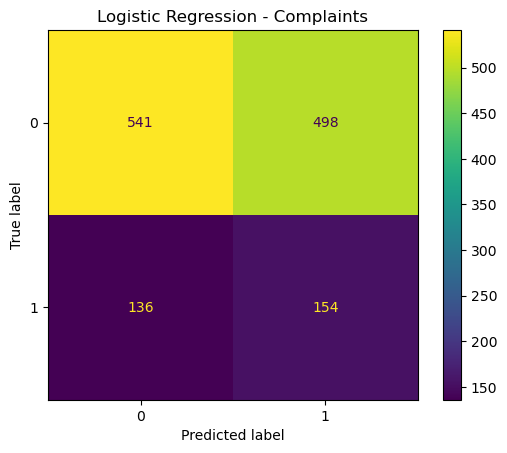

In [32]:
ConfusionMatrixDisplay.from_predictions(
    Y_test,
    log_pred
)

plt.title("Logistic Regression - Complaints")
plt.show()

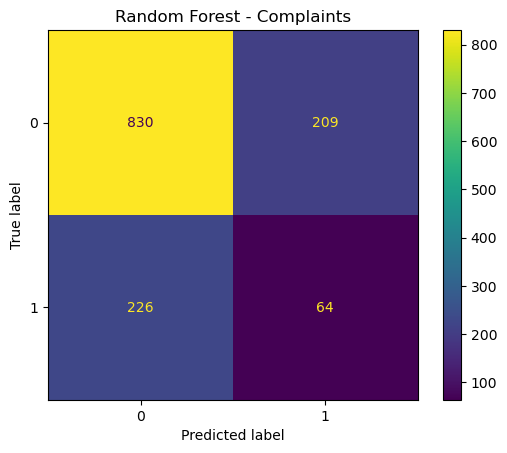

In [33]:
ConfusionMatrixDisplay.from_predictions(
    Y_test,
    RF_pred
)

plt.title("Random Forest - Complaints")
plt.show()

## Dataset 2 – Metro Median House Sales

The Metro Median House Sales dataset is analysed to check whether an area's median property price increased based on previous-period sales volume, median price and location.

In [34]:
# Load the prorperty sales dataset

property_df = pd.read_excel(
    r"Downloads\lsg_stats_2026_q1.xlsx"
)

property_df.head()

,City,Suburb,Sales 1Q 2025,Median 1Q 2025,Sales 1Q 2026,Median 1Q 2026,Median Change
0,ADELAIDE,ADELAIDE,6.0,1450000.0,8.0,1585000.0,0.093103
1,ADELAIDE,NORTH ADELAIDE,9.0,2282500.0,10.0,2480000.0,0.086528
2,ADELAIDE HILLS,ALDGATE,5.0,1600000.0,7.0,1625000.0,0.015625
3,ADELAIDE HILLS,ASHTON,1.0,1645000.0,NaN,NaN,NaN
4,ADELAIDE HILLS,BALHANNAH,4.0,776000.0,2.0,978500.0,0.260954


In [35]:
print(property_df.shape)
print(property_df.info())
print(property_df.isnull().sum())

(482, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 482 entries, 0 to 481
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   City            482 non-null    object 
 1   Suburb          482 non-null    object 
 2   Sales 1Q 2025   392 non-null    float64
 3   Median 1Q 2025  391 non-null    float64
 4   Sales 1Q 2026   397 non-null    float64
 5   Median 1Q 2026  397 non-null    float64
 6   Median Change   372 non-null    float64
dtypes: float64(5), object(2)
memory usage: 26.5+ KB
None
City                0
Suburb              0
Sales 1Q 2025      90
Median 1Q 2025     91
Sales 1Q 2026      85
Median 1Q 2026     85
Median Change     110
dtype: int64


In [36]:
property_df.describe()

,Sales 1Q 2025,Median 1Q 2025,Sales 1Q 2026,Median 1Q 2026,Median Change
count,392.000000,3.910000e+02,397.000000,3.970000e+02,372.000000
mean,10.992347,1.133613e+06,11.231738,1.274620e+06,0.157885
std,11.139085,5.242123e+05,11.080363,5.810051e+05,0.244838
min,1.000000,4.181000e+05,1.000000,5.360000e+05,-0.537217
25%,4.000000,7.915000e+05,4.000000,8.830000e+05,0.065380
50%,7.000000,9.483500e+05,8.000000,1.115750e+06,0.146606
75%,16.000000,1.319375e+06,14.000000,1.485500e+06,0.237313
max,89.000000,4.150000e+06,91.000000,6.572500e+06,2.480029


In [37]:
print(
    property_df["City"].value_counts()
)

City
ONKAPARINGA                     53
PORT ADELAIDE ENFIELD           52
ADELAIDE HILLS                  43
CHARLES STURT                   39
PLAYFORD                        38
MITCHAM                         32
SALISBURY                       32
BURNSIDE                        29
MARION                          28
WEST TORRENS                    26
TEA TREE GULLY                  23
NORWOOD PAYNEHAM & ST PETERS    21
UNLEY                           17
GAWLER                          14
HOLDFAST BAY                    12
PROSPECT                         9
CAMPBELLTOWN                     8
WALKERVILLE                      4
ADELAIDE                         2
Name: count, dtype: int64


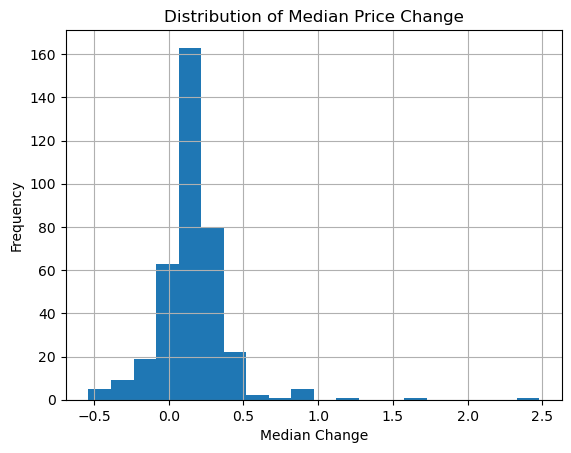

In [38]:
# Visualise distribution of median price changes

property_df["Median Change"].hist(
    bins=20
)

plt.title(
    "Distribution of Median Price Change"
)

plt.xlabel(
    "Median Change"
)

plt.ylabel(
    "Frequency"
)

plt.show()

### Target Definition

A binary target, `Price_Increased`, is created from Median Change. A value of 1 represents an increase in median property price, while 0 represents no increase. Records without a known Median Change are removed because their target outcome cannot be determined.

In [39]:
property_df = property_df.dropna(
    subset=["Median Change"]
)

In [40]:
property_df["Price_Increased"] = (
    property_df["Median Change"] > 0
).astype(int)

In [41]:
print(
    property_df["Price_Increased"]
    .value_counts()
)

Price_Increased
1    315
0     57
Name: count, dtype: int64


### Feature Selection and Missing Values

City, Sales 1Q 2025 and Median 1Q 2025 are used as predictors. Median Change is excluded because it reveals information about the target and could cause data leakage. City is converted into numerical dummy variables for modelling.

The data is divided into training and testing sets before missing values are handled. Missing sales and price values are replaced using medians calculated from the training data, preventing information from the test set to influence preprocessing.

In [42]:
X_property = property_df[
    [
        "City",
        "Sales 1Q 2025",
        "Median 1Q 2025"
    ]
].copy()

Y_property = property_df[
    "Price_Increased"
]

In [43]:
X_property = pd.get_dummies(
    X_property,
    columns=["City"],
    drop_first=True
)

In [44]:
Xp_train, Xp_test, Yp_train, Yp_test = train_test_split(
    X_property,
    Y_property,
    test_size=0.20,
    random_state=42,
    stratify=Y_property
)

In [45]:
sales_median = Xp_train["Sales 1Q 2025"].median()
price_median = Xp_train["Median 1Q 2025"].median()

In [46]:
Xp_test["Sales 1Q 2025"] = Xp_test[
    "Sales 1Q 2025"
].fillna(sales_median)

Xp_test["Median 1Q 2025"] = Xp_test[
    "Median 1Q 2025"
].fillna(price_median)

In [47]:
print(Xp_train.isnull().sum())
print(Xp_test.isnull().sum())

Sales 1Q 2025                        0
Median 1Q 2025                       0
City_ADELAIDE HILLS                  0
City_BURNSIDE                        0
City_CAMPBELLTOWN                    0
City_CHARLES STURT                   0
City_GAWLER                          0
City_HOLDFAST BAY                    0
City_MARION                          0
City_MITCHAM                         0
City_NORWOOD PAYNEHAM & ST PETERS    0
City_ONKAPARINGA                     0
City_PLAYFORD                        0
City_PORT ADELAIDE ENFIELD           0
City_PROSPECT                        0
City_SALISBURY                       0
City_TEA TREE GULLY                  0
City_UNLEY                           0
City_WALKERVILLE                     0
City_WEST TORRENS                    0
dtype: int64
Sales 1Q 2025                        0
Median 1Q 2025                       0
City_ADELAIDE HILLS                  0
City_BURNSIDE                        0
City_CAMPBELLTOWN                    0
City_CHARLES

#### Logistic Regression

In [48]:
property_scaler = StandardScaler()

Xp_train_scaled = property_scaler.fit_transform(Xp_train)
Xp_test_scaled = property_scaler.transform(Xp_test)

In [49]:
property_log = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

property_log.fit(
    Xp_train_scaled,
    Yp_train
)

LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)

#### Logistic Regression Predictions

In [50]:
property_log_pred = property_log.predict(
    Xp_test_scaled
)

property_log_prob = property_log.predict_proba(
    Xp_test_scaled
)[:, 1]

#### Random Forest

In [51]:
property_RF = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

property_RF.fit(
    Xp_train,
    Yp_train
)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

In [52]:
property_RF_pred = property_RF.predict(
    Xp_test
)

property_RF_prob = property_RF.predict_proba(
    Xp_test
)[:, 1]

### Property Model Evaluation

In [53]:
property_log_results = {
    "Accuracy": accuracy_score(
        Yp_test,
        property_log_pred
    ),
    "Precision": precision_score(
        Yp_test,
        property_log_pred
    ),
    "Recall": recall_score(
        Yp_test,
        property_log_pred
    ),
    "F1": f1_score(
        Yp_test,
        property_log_pred
    ),
    "ROC-AUC": roc_auc_score(
        Yp_test,
        property_log_prob
    )
}

In [54]:
property_RF_results = {
    "Accuracy": accuracy_score(
        Yp_test,
        property_RF_pred
    ),
    "Precision": precision_score(
        Yp_test,
        property_RF_pred
    ),
    "Recall": recall_score(
        Yp_test,
        property_RF_pred
    ),
    "F1": f1_score(
        Yp_test,
        property_RF_pred
    ),
    "ROC-AUC": roc_auc_score(
        Yp_test,
        property_RF_prob
    )
}

In [55]:
property_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        property_log_results["Accuracy"],
        property_RF_results["Accuracy"]
    ],
    "Precision": [
        property_log_results["Precision"],
        property_RF_results["Precision"]
    ],
    "Recall": [
        property_log_results["Recall"],
        property_RF_results["Recall"]
    ],
    "F1": [
        property_log_results["F1"],
        property_RF_results["F1"]
    ],
    "ROC-AUC": [
        property_log_results["ROC-AUC"],
        property_RF_results["ROC-AUC"]
    ]
})

print(property_results)

                 Model  Accuracy  Precision    Recall        F1   ROC-AUC
0  Logistic Regression  0.853333   0.964912  0.859375  0.909091  0.843750
1        Random Forest  0.893333   0.888889  1.000000  0.941176  0.772727


#### Property Model Results

Both models performed better on the property dataset than on the complaints dataset. The results are compared using accuracy, precision, recall, F1-score and ROC-AUC rather than relying on a single metric. Differences between the models show that the preferred model depends on the business objective.

### Feature Insights – Random Forest

In [56]:
property_importance = pd.DataFrame({
    "Feature": X_property.columns,
    "Importance": property_RF.feature_importances_
})

property_importance = (
    property_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

print(
    property_importance.head(10)
)

                              Feature  Importance
1                      Median 1Q 2025    0.462321
0                       Sales 1Q 2025    0.294383
11                   City_ONKAPARINGA    0.025214
17                         City_UNLEY    0.022220
7                   City_HOLDFAST BAY    0.020741
10  City_NORWOOD PAYNEHAM & ST PETERS    0.018663
13         City_PORT ADELAIDE ENFIELD    0.018424
2                 City_ADELAIDE HILLS    0.016290
9                        City_MITCHAM    0.015938
5                  City_CHARLES STURT    0.015101


### Feature Insights – Logistic Regression

In [57]:
property_coefficients = pd.DataFrame({
    "Feature": X_property.columns,
    "Coefficient": property_log.coef_[0]
})

property_coefficients["Absolute"] = abs(
    property_coefficients["Coefficient"]
)

property_coefficients = (
    property_coefficients
    .sort_values(
        "Absolute",
        ascending=False
    )
)

print(
    property_coefficients.head(10)
)

                       Feature  Coefficient  Absolute
1               Median 1Q 2025    -1.196349  1.196349
0                Sales 1Q 2025     0.870171  0.870171
7            City_HOLDFAST BAY     0.738580  0.738580
11            City_ONKAPARINGA    -0.640833  0.640833
15              City_SALISBURY     0.431949  0.431949
12               City_PLAYFORD     0.425940  0.425940
13  City_PORT ADELAIDE ENFIELD    -0.421918  0.421918
16         City_TEA TREE GULLY    -0.362736  0.362736
4            City_CAMPBELLTOWN     0.346865  0.346865
6                  City_GAWLER    -0.294111  0.294111


### Property Model Insights

The two models provide complementary information about the factors associated with median-price increases. Previous median price, sales activity and location can be compared across both models to determine which features are most useful for predicting whether prices increased.

However, these findings represent predictive associations rather than direct causes of price increase. The relatively small dataset and limited time period should also be considered when interpreting the results, as they may limit how widely the results can be applied.

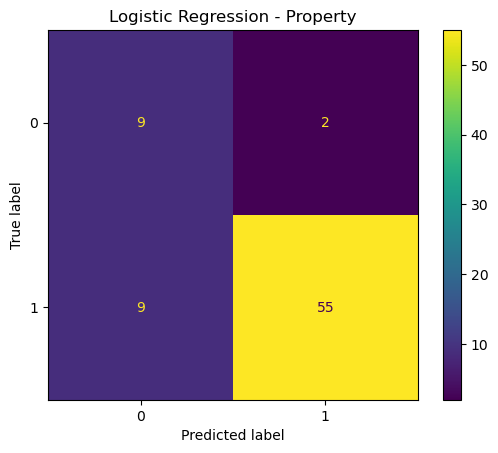

In [58]:
ConfusionMatrixDisplay.from_predictions(
    Yp_test,
    property_log_pred
)

plt.title("Logistic Regression - Property")
plt.show()

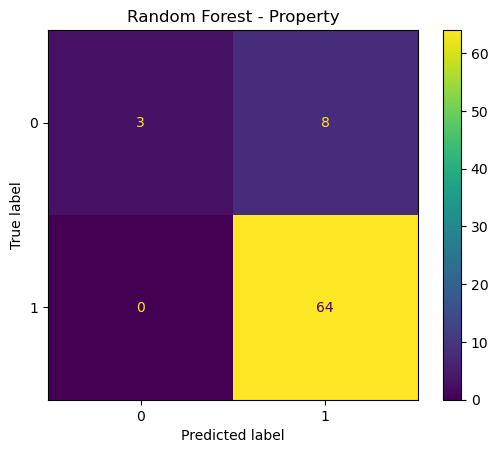

In [59]:
ConfusionMatrixDisplay.from_predictions(
    Yp_test,
    property_RF_pred
)

plt.title("Random Forest - Property")
plt.show()

## Evaluation Metric Justification

Accuracy, precision, recall, F1-score and ROC-AUC are used to evaluate model effectiveness.

For the complaints dataset, recall and F1-score are particularly important because the vulnerable-group class is underrepresented. Accuracy alone can be misleading if a model performs well mainly on the majority class. Recall shows how many actual vulnerable-group cases are identified, while F1-score balances recall and precision.

For the property dataset, accuracy shows overall prediction performance, while precision and recall show how well teh models identify price increase without producing too many incorrect predictions. F1-score balances these measures, and ROC-AUC evaluates how effectively each model distinguishes between increasing and non-increasing prices overall.

## Comparison of Data Sources and Models

Both datasets provide useful insights, but their usefulness differs. The property dataset produces stronger predictive performance, suggesting that the available property features provide more useful information for its classification target. In contrast, the complaints dataset produces weaker predictive performance, indicating that the available complaint features alone may be insufficient for reliable vulnerability classification.

The findings are complementary rather than contradictory because the datasets address different Business Analyst problems. The complaints dataset provides customer and service-related insights, while the property dataset provides market and sales-related insights. Together, they demonstrate that machine learning performance depends not only on the model but also on the relevance and quality of the available data.

## Limitations

The complaints dataset covers only one quarter, and the vulnerable-group status is self-reported, limiting the conclusions that can be drawn. Its available attributes also provide relatively weak predictive information for the target.

The property dataset is relatively small and covers only a limited time period, which may reduce the reliability of the results to other periods or regions. In both analysis, model outputs identify predictive relationships rather than causal relationships.